# Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "darkgrid")

try:
    df = pd.read_csv('train.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo .csv. Por favor, cárgalo en el entorno.")
    
df.head()

Dataset cargado exitosamente.


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


# Limpieza de datos

## Eliminacion de datos duplicados

In [3]:
import pandas as pd
import numpy as np

# =========================
# LEER ARCHIVO
# =========================
df = pd.read_csv('train.csv')

# =========================
# ELIMINAR DUPLICADOS
# =========================
df.drop_duplicates(inplace=True)

# =========================
# LIMPIEZA DE TIPOS DE DATOS
# =========================

# host_response_rate suele venir como "95%"
if 'host_response_rate' in df.columns:
    
    df['host_response_rate'] = (
        df['host_response_rate']
        .astype(str)
        .str.replace('%', '', regex=False)
    )

    df['host_response_rate'] = pd.to_numeric(
        df['host_response_rate'],
        errors='coerce'
    )

# zipcode NO debe tratarse como numérico
df['zipcode'] = df['zipcode'].astype(str)

# =========================
# LIMPIEZA DE VALORES FALTANTES
# =========================

# 1. Variables numéricas
columnas_numericas = [
    'bathrooms',
    'host_response_rate',
    'review_scores_rating',
    'bedrooms',
    'beds'
]

# Convertir a numérico por seguridad
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Rellenar nulos con mediana
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

# 2. Variables categóricas
columnas_categoricas = [
    'property_type',
    'room_type',
    'bed_type',
    'cancellation_policy',
    'city',
    'host_has_profile_pic',
    'host_identity_verified',
    'neighbourhood',
    'zipcode'
]

for col in columnas_categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Columnas de texto
df['description'] = df['description'].fillna("Sin descripción")
df['name'] = df['name'].fillna("Sin nombre")

# =========================
# ELIMINAR COLUMNAS INNECESARIAS
# =========================

if 'thumbnail_url' in df.columns:
    df.drop(columns=['thumbnail_url'], inplace=True)

# =========================
# CORRECCIÓN DE VALORES ATÍPICOS
# =========================

# Eliminar coordenadas inválidas
df = df[
    (df['latitude'].between(-90, 90)) &
    (df['longitude'].between(-180, 180))
]

# Eliminar valores extremos
df = df[df['bathrooms'] < 20]
df = df[df['bedrooms'] < 20]
df = df[df['beds'] < 30]

# Ratings válidos
df = df[
    (df['review_scores_rating'] >= 0) &
    (df['review_scores_rating'] <= 100)
]

# =========================
# VERIFICAR RESULTADOS
# =========================

print("===== TIPOS DE DATOS =====")
print(df.dtypes)

print("\n===== VALORES FALTANTES =====")
print(df.isnull().sum())

print("\n===== DIMENSIONES FINALES =====")
print(df.shape)

print("\n===== INFORMACIÓN GENERAL =====")
print(df.info())

# =========================
# GUARDAR DATASET LIMPIO
# =========================

df.to_csv('train_limpio.csv', index=False)

print("\nArchivo limpio guardado correctamente.")

===== TIPOS DE DATOS =====
id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate        float64
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

===== 

## Variable dependiente:

Precio, porque depende en donde y que contiene el airbnb

## Variable indpendiente:

Las variables independientes son aquellas utilizadas para explicar o predecir el precio del alojamiento, entre ellas:

bathrooms, bedrooms, beds, property_type, room_type, etc.


## Selección de características

Resumidamente puedes incliuir que tan recomendadas estan estos airbnbs, dependendiendo de la calificacion que las personas hayan puesto en las reviws

## Análisis de correlación

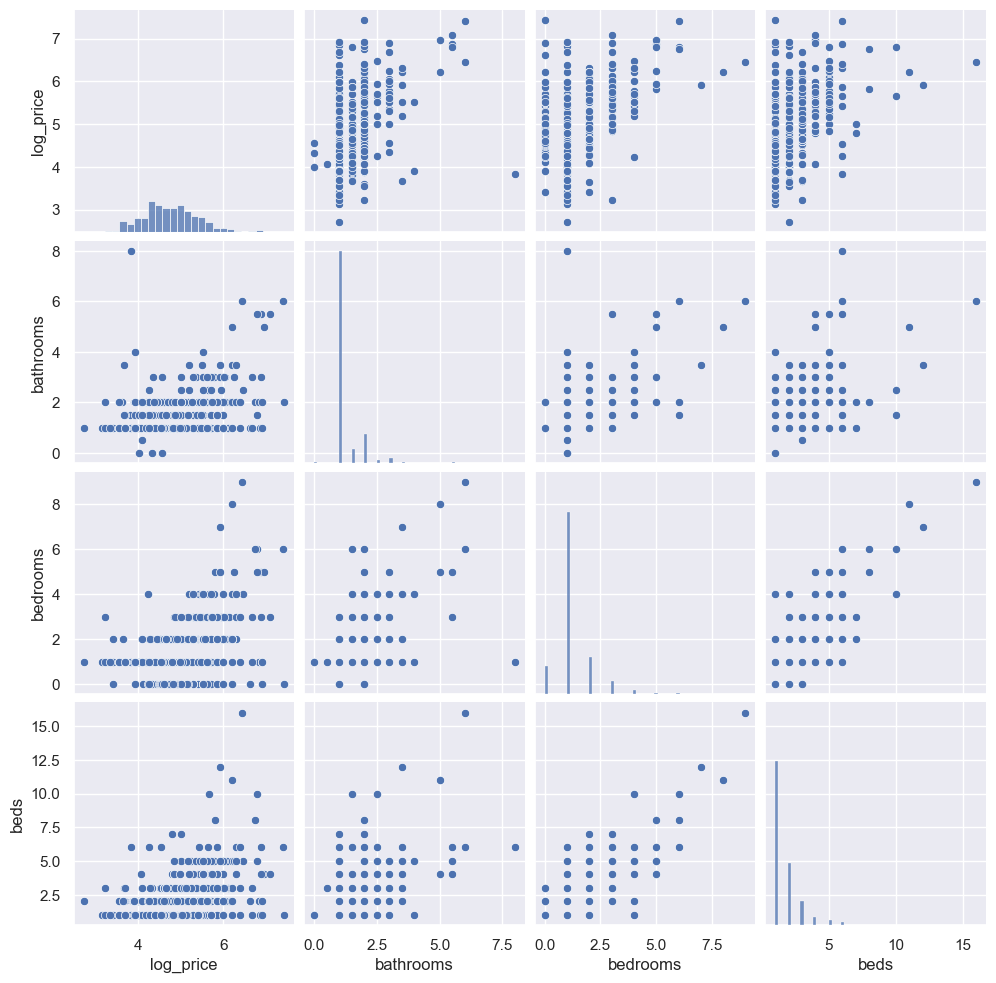

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_pairplot = [
    'log_price',
    'bathrooms',
    'bedrooms',
    'beds',
]

sample_size = min(1000, len(df))

data = (
    df[variables_pairplot]
    .dropna()
    .sample(sample_size, random_state=42)
)

sns.pairplot(
    data,
    diag_kind='hist'
)

plt.show()

# Division de datos

In [5]:
from sklearn.model_selection import train_test_split

X = df[[
    'accommodates',
    'bathrooms',
    'bedrooms',
    'latitude',
    'longitude',
    'number_of_reviews',
    'cleaning_fee'
]]

y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6

In [6]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


       Valor Real  Predicción
4079     3.806662    4.754561
33735    4.941642    4.595851
69475    4.941642    5.120254
454      4.867534    5.199917
25153    3.663562    4.520139
42304    4.836282    5.229735
22686    5.220356    5.282108
20776    5.686975    4.485298
14934    3.555348    4.551628
39634    4.234107    4.927845
MSE: 0.34017434065180846
R²: 0.3378290998784734


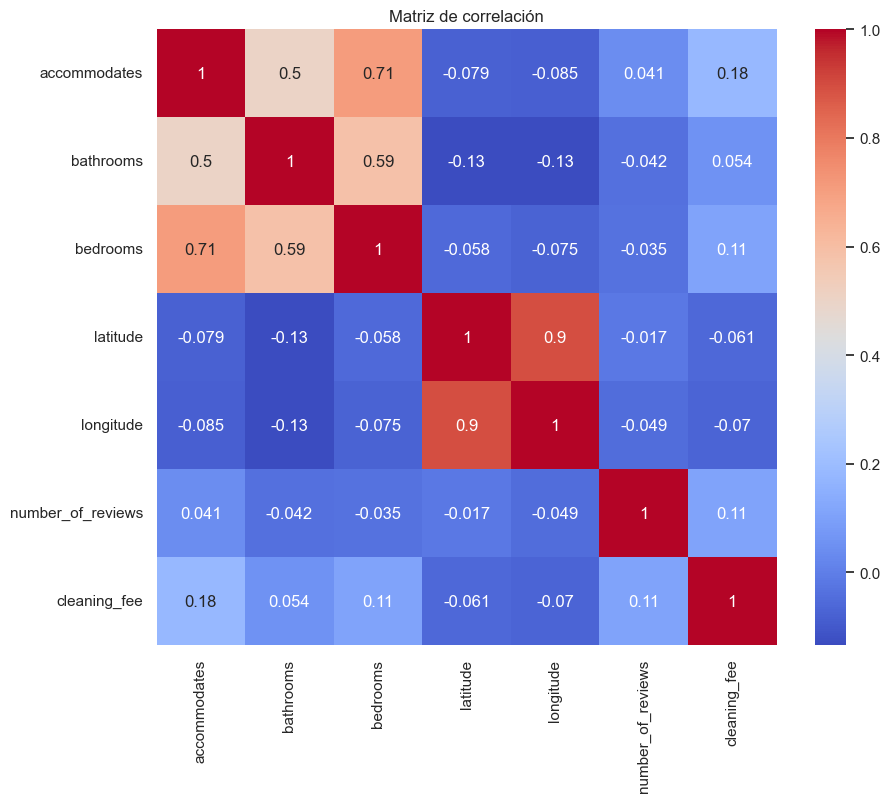

In [8]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    'Valor Real': y_test,
    'Predicción': y_pred
})

print(comparacion.head(10))

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

import seaborn as sns
import matplotlib.pyplot as plt

corr = X_train.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()